In [ ]:
import os

In [ ]:
import matplotlib.pyplot as plt

## Import TensorFlow / Keras

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

## Mount Google Driven in Colab Content

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## This was the dataswr i sued to train a CNN on rice panicles
https://www.kaggle.com/datasets/rajkumar898/rice-plant-dataset

### Copy dataset from drive to colab content

In [ ]:
!cp "/content/drive/MyDrive/RiceLeaves/Rice_Plant_Dataset.zip" /content/

In [ ]:
!unzip -q "/content/Rice_Plant_Dataset.zip" -d /content/

In [ ]:
IMG_SIZE = (  640, 640 )

In [ ]:
BATCH_SIZE = 16

In [ ]:
DATASET_DIR = "/content/Rice_Dataset"

## Pipeline

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.16,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)


Found 1007 files belonging to 2 classes.
Using 846 files for training.


In [ ]:
global_class_names = train_ds.class_names # Store class names before prefetching

In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.16,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 1007 files belonging to 2 classes.
Using 161 files for validation.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1)
])


In [ ]:
# EfficientNetB0 is the most lightweight model
base_model = applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,       # renove the original head from imagenet, I do not need it
    weights='imagenet'   # I use pre-trained weights.  betteer than trainign from scratch
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
base_model.trainable = False  # freeze backbone

In [ ]:
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

In [ ]:
# I ought to apply Data Augmentations,  rice-plants is small dataset ~ 1000 images is small size
x = data_augmentation(inputs)

In [ ]:
# ImageNet same pre-processing,
x = applications.efficientnet.preprocess_input(x)

In [ ]:
# CNN Feature Extractions set up
x = base_model(x, training=False)

In [ ]:
#  CNN Header
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x) # Ayuda a evitar sobreajuste

In [ ]:
# Last Layer , I just need one single neuron binary classfifer with Sigmoid is Enough
# I just need  a lightweight that says if a rice panicle  spike is health or bad.
outputs = layers.Dense(1, activation='sigmoid')(x)

In [ ]:
model = models.Model(inputs, outputs)

## Check my custome EfficientNet model backbone parameters at phase1

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 640, 640, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 640, 640, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 20, 20, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
## most of my hyperparameters are frozen, I set them to be frozen.  go on

In [ ]:
# Compile wht model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'), # I want to see how does it go
        tf.keras.metrics.Recall(name='recall')   #  Recall is important for my bin classification problem
    ]
) #  model is done

In [ ]:
# 6. CALLBACKS

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
    ModelCheckpoint('mejor_modelo_arroz.h5', monitor='val_accuracy', save_best_only=True)
]


In [ ]:
## Start Training first Stage I
## Most of the params are all freeze layers

In [ ]:
print("Phase I  ")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Phase I  
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.7105 - loss: 0.6065 - precision: 0.7308 - recall: 0.6877

53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 303ms/step - accuracy: 0.8109 - loss: 0.4528 - precision: 0.8239 - recall: 0.8050 - val_accuracy: 0.8758 - val_loss: 0.4039 - val_precision: 0.8205 - val_recall: 0.9143 - learning_rate: 0.0010
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.8508 - loss: 0.3951 - precision: 0.8430 - recall: 0.8669

53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 244ms/step - accuracy: 0.8759 - loss: 0.3194 - precision: 0.8736 - recall: 0.8876 - val_accuracy: 0.9006 - val_loss: 0.3255 - val_precision: 0.9091 - val_recall: 0.8571 - learning_rate: 0.0010
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 238ms/step - accuracy: 0.8972 - loss: 0.2735 - precision: 0.9011 - recall: 0.8991 - val_accuracy: 0.8820 - val_loss: 0.2914 - val_precision: 0.9322 - val_recall: 0.7857 - learning_rate: 0.0010
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 239ms/step - accuracy: 0.9007 - loss: 0.2258 - precision: 0.9055 - recall: 0.9014 - val_accuracy: 0.8882 - val_loss: 0.2541 - val_precision: 0.8514 - val_recall: 0.9000 - learning_rate: 0.0010
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 238ms/step - accuracy: 0.9102 - loss: 0.2322 - precision: 0.9265 - recall: 0.8968 - val_accuracy: 0.8820 - val_loss: 0.2456 - val_precision: 0.8592 - val_recall: 0.8714 - learning_rate: 0.0010
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9265 

53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.9161 - loss: 0.2243 - precision: 0.9176 - recall: 0.9197 - val_accuracy: 0.9193 - val_loss: 0.2265 - val_precision: 0.9385 - val_recall: 0.8714 - learning_rate: 0.0010
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.9421 - loss: 0.1793 - precision: 0.9469 - recall: 0.9404 - val_accuracy: 0.9006 - val_loss: 0.2668 - val_precision: 0.8462 - val_recall: 0.9429 - learning_rate: 0.0010
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9420 - loss: 0.1599 - precision: 0.9336 - recall: 0.9544

53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 244ms/step - accuracy: 0.9291 - loss: 0.1852 - precision: 0.9393 - recall: 0.9220 - val_accuracy: 0.9255 - val_loss: 0.2122 - val_precision: 0.8919 - val_recall: 0.9429 - learning_rate: 0.0010
Epoch 9/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.9267 - loss: 0.1634 - precision: 0.9289 - recall: 0.9289 - val_accuracy: 0.8882 - val_loss: 0.2978 - val_precision: 0.8333 - val_recall: 0.9286 - learning_rate: 0.0010
Epoch 10/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.9480 - loss: 0.1367 - precision: 0.9516 - recall: 0.9472 - val_accuracy: 0.8944 - val_loss: 0.3018 - val_precision: 0.9206 - val_recall: 0.8286 - learning_rate: 0.0010
Epoch 11/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.9515 - loss: 0.1187 - precision: 0.9418 - recall: 0.9656 - val_accuracy: 0.8944 - val_loss: 0.2756 - val_precision: 0.9077 - val_recall: 0.8429 - learning_rate: 2.0000e-04
Epoch 12/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 237ms/step - accuracy:

In [ ]:
## Unfreezed last layer to adapt rice panicles features

In [ ]:
base_model.trainable = True

In [ ]:
# Freeze everything except the CNN top layers , they are done
for layer in base_model.layers[:-15]:
    layer.trainable = False


In [ ]:
model.compile(  # R :Compile the model bakc again
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)


In [ ]:
model.summary()   #  Check hyperparams  with TF

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 640, 640, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 640, 640, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 20, 20, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 1,223,985 (4.67 MB)

 Non-trainable params: 3,158,899 (12.05 MB)

In [ ]:
# Start trainign Phase II

In [ ]:
print(" PHASE II -FINE -TUNING")
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

 PHASE II -FINE -TUNING
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 293ms/step - accuracy: 0.9291 - loss: 0.1823 - val_accuracy: 0.9130 - val_loss: 0.2480 - learning_rate: 1.0000e-04
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 242ms/step - accuracy: 0.9397 - loss: 0.1426 - val_accuracy: 0.9193 - val_loss: 0.2971 - learning_rate: 1.0000e-04
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step - accuracy: 0.9586 - loss: 0.1043 - val_accuracy: 0.9193 - val_loss: 0.2957 - learning_rate: 2.0000e-05
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step - accuracy: 0.9539 - loss: 0.1213 - val_accuracy: 0.9193 - val_loss: 0.2743 - learning_rate: 2.0000e-05
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 242ms/step - accuracy: 0.9657 - loss: 0.1139 - val_accuracy: 0.9193 - val_loss: 0.2710 - learning_rate: 4.0000e-06


In [ ]:
## I  Sabe my bwst .keras model  as ONNX optimized Grpahs

In [ ]:
!pip install tf2onnx onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 132.2 MB/s eta 0:00:00


In [ ]:
# Import  tf2onnx to export 2 onnx

In [ ]:

import tf2onnx
import onnx

In [ ]:
#  save best model and download it ASAP before Colab Vm dies

In [ ]:
model = tf.keras.models.load_model('/content/best_rice_panicle_model.h5')

In [ ]:
IMG_SIZE =  640  # same img size I train this CNN

In [ ]:
TEST_DIR = "/content/images2test"

In [ ]:
TEST_DIR =  "/content/testing"

In [ ]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image


In [ ]:
# Use the globally stored class names
class_names = global_class_names

plt.figure(figsize=(20, 15))

In [ ]:
# Get the list of image files from the TEST_DIR
image_files = [os.path.join(TEST_DIR, f) for f in os.listdir(TEST_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


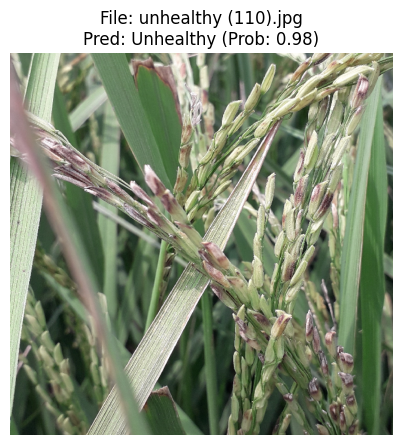

In [ ]:

if not image_files:
    print(f"No image files found in {TEST_DIR}")
else:
    for i, img_path in enumerate(image_files):
        if i >= 10: # Limit to 10 images for display purposes
            break

        img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) # Create a batch

        # Preprocess the image using EfficientNet's preprocess_input
        preprocessed_img = applications.efficientnet.preprocess_input(img_array)

        predictions = model.predict(preprocessed_img)

        # For binary classification (sigmoid output), a threshold of 0.5 is common
        predicted_class_index = (predictions[0][0] > 0.5).astype(int)
        predicted_class_name = class_names[predicted_class_index]

        # Extract filename for display
        filename = os.path.basename(img_path)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img) # Display the original image
        plt.title(f"File: {filename}\nPred: {predicted_class_name} (Prob: {predictions[0][0]:.2f})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
#  Save Tensors

In [ ]:
input_signature = [tf.TensorSpec([1, IMG_SIZE, IMG_SIZE, 3], tf.float32, name='input')]


In [ ]:
onnx_model, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=input_signature,
    opset=16
)


In [ ]:
# Ensore model is saved and download

In [ ]:
onnx.save(onnx_model, "Rice_Spike_Model.onnx")